In [5]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector

NanoAODSchema.warn_missing_crossrefs = False

# IGNORE THE WARNING 

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [6]:
# Datasets:
#/BulkGravToWW_narrow_M-*_13TeV-madgraph/*NanoAODv7*/NANOAODSIM
#/RSGravToWWToWlepWhad_width0p1_M-*_TuneCUETP8M1_13TeV-madgraph-pythia8/*NanoAODv3*/NANOAODSIM


# When having a large number of files it is useful to put the list on a separate file.
# import json

# with open("semileptonic_notebooks/samples.json", 'r') as sample_file:
#     fileset = json.load(sample_file)

# for sample in fileset:
#     print(sample)

# For now we are only testing on a limited number of files so they are just listed here
fileset = {
    'BulkGravToWW': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/D4404DCB-FBF8-C640-87B0-2DA1D5139083.root': "Events",
        },
        'metadata': {
            'is_mc': 'Events',
        },
    },
    'RSGravToWW': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv3/RSGravToWWToWlepWhad_width0p1_M-1200_TuneCUETP8M1_13TeV-madgraph-pythia8/NANOAODSIM/PUMoriond17_94X_mcRun2_asymptotic_v3-v1/60000/4442437A-52BB-E811-A8DA-90E2BACC5EEC.root': "Events",
          },
        'metadata': {
            'is_mc': 'Events',
        },
    }
}

In [29]:
# This step takes some time because it is loading the events
test_dataset = 'BulkGravToWW'
events = NanoEventsFactory.from_root(
    fileset[test_dataset]['files'],
    entry_stop = 1000, # this limit the number of events, good to experiment more quickly
    metadata = fileset[test_dataset]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()

# Load RSGraviton
rs_dataset = 'RSGravToWW'
rs_events = NanoEventsFactory.from_root(
    fileset[rs_dataset]['files'],
    entry_stop=1000,
    metadata=fileset[rs_dataset]['metadata'],
    schemaclass=NanoAODSchema,
    delayed=False,
).events()

In [8]:
print('Lets get familiar with what is inside an event of a NanoAOD file:')
events.fields


print('Now we want to learn about the particles in our events')

print(type(events.GenPart))
print(events.GenPart.fields)

Lets get familiar with what is inside an event of a NanoAOD file:
Now we want to learn about the particles in our events
<class 'coffea.nanoevents.methods.nanoaod.GenParticleArray'>
['eta', 'mass', 'phi', 'pt', 'genPartIdxMother', 'pdgId', 'status', 'statusFlags', 'genPartIdxMotherG', 'distinctParentIdxG', 'childrenIdxG', 'distinctChildrenIdxG', 'distinctChildrenDeepIdxG']


### TASK 1: 
Understand the meaning of the GenPart fields that you should have printed. Some are more easy then others. For now you should make sure you understand 'eta', 'mass', 'phi', 'pt', 'genPartIdxMother', 'pdgId'

### TASK 2: 
Can you select the W bosons? Can you print the value of the W boson mass? And plot?


W boson mass values:
[80.8, 78.2, 79, 80.2, 80, 79.5, 80.8, ..., 85.8, 83, 83, 81.2, 76.2, 77, 80.2]


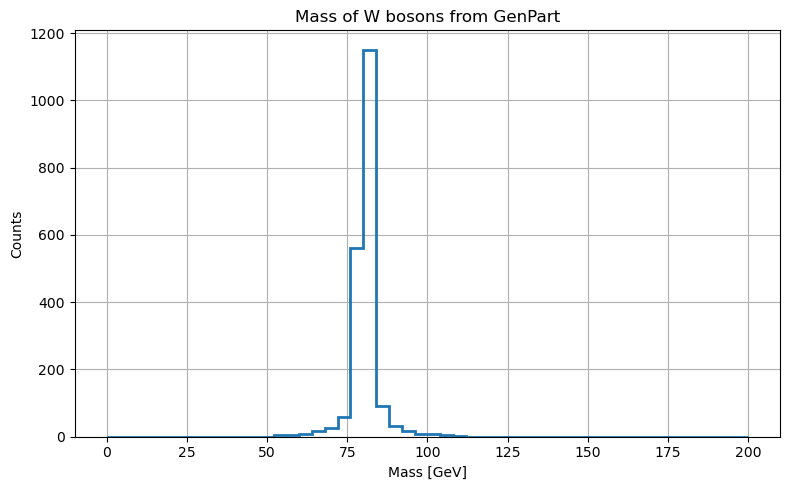

In [10]:
# Implement here your code
w_mask = abs(events.GenPart.pdgId) == 24
w_bosons = events.GenPart[w_mask]

# Print W boson mass (raw awkward array)
print("W boson mass values:")
print(ak.flatten(w_bosons.mass))

# Plot W boson mass
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(w_bosons.mass)), bins=50, range=(0, 200), histtype='step', linewidth=2)
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("Mass of W bosons from GenPart")
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 3:

Plot also the other kinematic variables

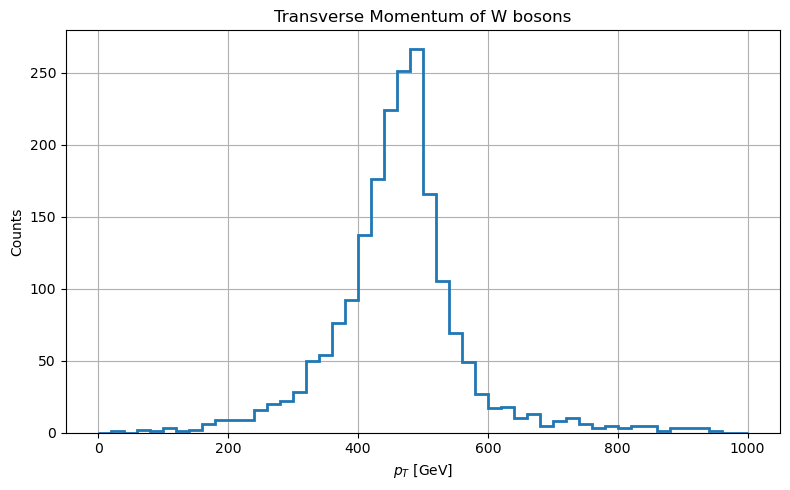

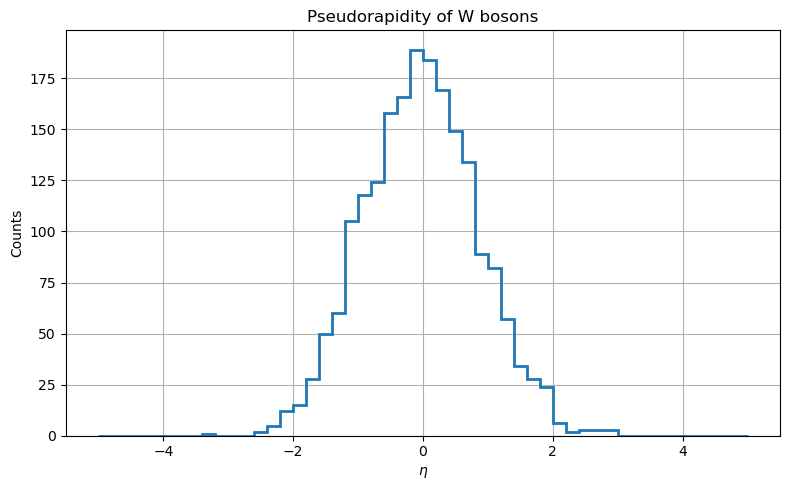

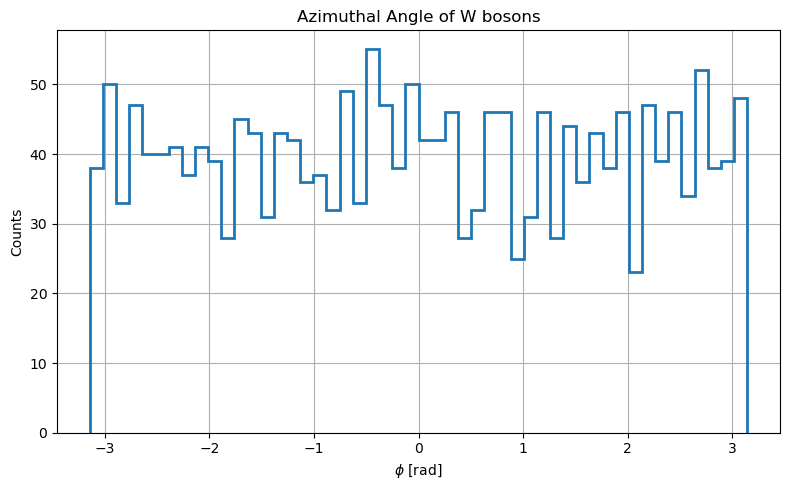

In [11]:
# Implement here your code
# Select W bosons
w_mask = abs(events.GenPart.pdgId) == 24
w_bosons = events.GenPart[w_mask]

# Flatten for plotting
w_pt = ak.to_numpy(ak.flatten(w_bosons.pt))
w_eta = ak.to_numpy(ak.flatten(w_bosons.eta))
w_phi = ak.to_numpy(ak.flatten(w_bosons.phi))

# Plot pt
plt.figure(figsize=(8, 5))
plt.hist(w_pt, bins=50, range=(0, 1000), histtype='step', linewidth=2)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Transverse Momentum of W bosons")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot eta
plt.figure(figsize=(8, 5))
plt.hist(w_eta, bins=50, range=(-5, 5), histtype='step', linewidth=2)
plt.xlabel(r"$\eta$")
plt.ylabel("Counts")
plt.title("Pseudorapidity of W bosons")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot phi
plt.figure(figsize=(8, 5))
plt.hist(w_phi, bins=50, range=(-np.pi, np.pi), histtype='step', linewidth=2)
plt.xlabel(r"$\phi$ [rad]")
plt.ylabel("Counts")
plt.title("Azimuthal Angle of W bosons")
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 4: 
Now identify the quarks coming from the W bosons and plot their kinematic variables


<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_201/33792876.py:36: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Quarks from W: $\eta$")
/tmp/ipykernel_201/33792876.py:45: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Quarks from W: $\phi$")


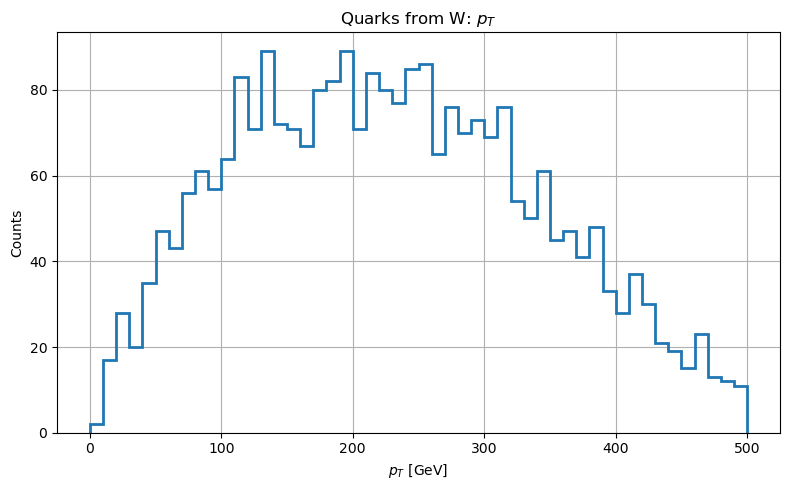

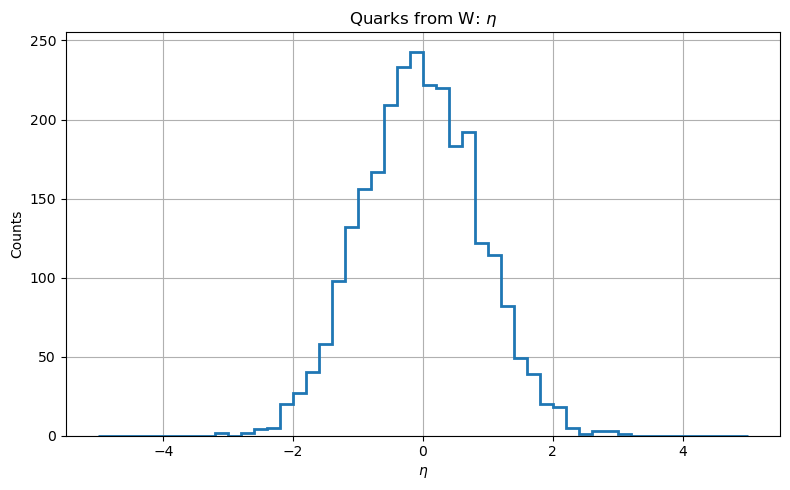

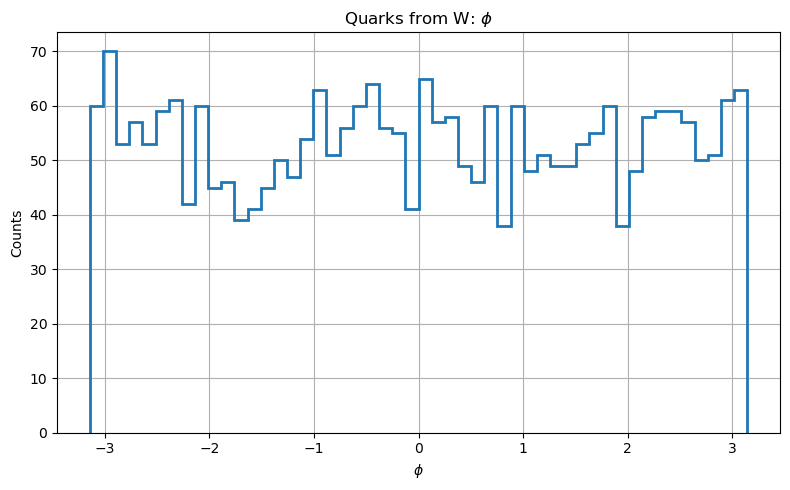

In [13]:
# Implement here your code 
# This starts to get more complicated! Take your time to think!

# Step 1: Get all GenParticles
genparts = events.GenPart

# Step 2: Identify quarks (PDG ID 1–6 and -1 to -6)
is_quark = (abs(genparts.pdgId) <= 6) & (abs(genparts.pdgId) >= 1)

# Step 3: Get the mother's index for each GenPart
mother_idx = genparts.genPartIdxMother

# Step 4: Get the mother particle for each GenPart
mother = genparts[mother_idx]

# Step 5: Check which quarks have a W boson as their mother
comes_from_W = (abs(mother.pdgId) == 24)

# Step 6: Apply both masks
quarks_from_W = genparts[is_quark & comes_from_W]

# Step 7: Plot kinematic variables
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(quarks_from_W.pt)), bins=50, range=(0, 500), histtype='step', linewidth=2)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Quarks from W: $p_T$")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(quarks_from_W.eta)), bins=50, range=(-5, 5), histtype='step', linewidth=2)
plt.xlabel(r"$\eta$")
plt.ylabel("Counts")
plt.title("Quarks from W: $\eta$")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(quarks_from_W.phi)), bins=50, range=(-np.pi, np.pi), histtype='step', linewidth=2)
plt.xlabel(r"$\phi$")
plt.ylabel("Counts")
plt.title("Quarks from W: $\phi$")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Bonus task:

Are there many quarks not coming from the Ws? Would your answer be different if you would be using Vector Boson Scattering samples? Remind me about it at some point and we may give it a go :)

In [21]:
# --- Step 1: Identify all quarks in the event ---
all_quarks_mask = (abs(genparts.pdgId) >= 1) & (abs(genparts.pdgId) <= 6)
all_quarks = genparts[all_quarks_mask]

# --- Step 2: Identify W bosons ---
w_mask = abs(genparts.pdgId) == 24
w_bosons = genparts[w_mask]

# --- Step 3: Get the indices of W bosons using local index ---
# gives the index of each GenPart within its event
genpart_indices = ak.local_index(genparts, axis=1)
w_indices = genpart_indices[w_mask]

# --- Step 4: Get the mother indices of all quarks ---
# These are the indices (within the same event) of the particle each quark came from
quark_mother_indices = genparts.genPartIdxMother[all_quarks_mask]

# --- Step 5: Flatten the W indices and quark mother indices for comparison ---
# We flatten to compare all quarks across all events in a single array
w_index_set = set(ak.to_list(ak.flatten(w_indices)))
flat_quark_mothers = ak.to_numpy(ak.flatten(quark_mother_indices))

# --- Step 6: Build a boolean mask for whether each quark's mother is a W boson ---
# This is a simple Python loop comparison because awkward doesn't support isin on nested records
quark_from_W_bool = np.array([mom in w_index_set for mom in flat_quark_mothers])

# --- Step 7: Flatten the quarks array itself for direct masking ---
flat_quarks = ak.flatten(all_quarks)

# --- Step 8: Separate quarks based on origin ---
quarks_from_W = flat_quarks[quark_from_W_bool]
quarks_not_from_W = flat_quarks[~quark_from_W_bool]

print(f"Total quarks: {len(flat_quarks)}")
print(f"→ Quarks from W bosons: {len(quarks_from_W)}")
print(f"→ Quarks NOT from W bosons: {len(quarks_not_from_W)}")
print(f"→ Fraction NOT from W: {len(quarks_not_from_W)/len(flat_quarks):.2%}")

Total quarks: 9152
→ Quarks from W bosons: 5764
→ Quarks NOT from W bosons: 3388
→ Fraction NOT from W: 37.02%


## Polarization variable cos theta

To calculate this variable we are putting together some of the things you have been working on before. Two functions have already been implemented for you. Read them below and try to understand what they do. Add all printouts that you need. Also printing the type of the variables is useful. Or running on a small number of events to explore them in depth.

In [22]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
def get_w_decay_quark_pairs_gen(events):
    """
    Extraction of pairs of quarks coming from a W boson at generator level
    Gave a 'vector.Momentum4D'.
    """
    if events is None or len(events) == 0:
        return []
        
    pdgId = events.GenPart.pdgId
    mothers = events.GenPart.genPartIdxMother
    
    all_quark_pairs_vectors = []

    print(f"[INFO] Processing events to find W -> qq'.")
    num_w_decay_to_quarks = 0
    for i in range(len(events)): 
        event_pdgId = pdgId[i]
        event_mothers = mothers[i]
        
        # Label of the W boson in the actual event
        # abs(pdgId) == 24 for W+ and W-
        w_indices_in_event = ak.local_index(event_pdgId)[abs(event_pdgId) == 24]

        for w_idx in w_indices_in_event:
            # Indexes for the quarks doughters coming from to the W (abs(pdgId) between 1 and 6)
            daughter_indices = ak.local_index(event_pdgId)[
                (event_mothers == w_idx) & (abs(event_pdgId) >= 1) & (abs(event_pdgId) <= 6)
            ]
            
            if len(daughter_indices) == 2:
                num_w_decay_to_quarks += 1
                q1_data = {
                    "pt": events.GenPart.pt[i][daughter_indices[0]],
                    "eta": events.GenPart.eta[i][daughter_indices[0]],
                    "phi": events.GenPart.phi[i][daughter_indices[0]],
                    "mass": events.GenPart.mass[i][daughter_indices[0]],
                }
                q2_data = {
                    "pt": events.GenPart.pt[i][daughter_indices[1]],
                    "eta": events.GenPart.eta[i][daughter_indices[1]],
                    "phi": events.GenPart.phi[i][daughter_indices[1]],
                    "mass": events.GenPart.mass[i][daughter_indices[1]],
                }
                q1_vec = vector.obj(pt=q1_data["pt"], eta=q1_data["eta"], phi=q1_data["phi"], mass=q1_data["mass"])
                q2_vec = vector.obj(pt=q2_data["pt"], eta=q2_data["eta"], phi=q2_data["phi"], mass=q2_data["mass"])
                all_quark_pairs_vectors.append([q1_vec, q2_vec])
                
    print(f"[INFO] Found {len(all_quark_pairs_vectors)} pairs of quarks {num_w_decay_to_quarks} for W->qq'.")
    return all_quark_pairs_vectors


In [32]:
w_decay_quark_pairs_gen = get_w_decay_quark_pairs_gen(events)

[INFO] Processing events to find W -> qq'.
[INFO] Found 1335 pairs of quarks 1335 for W->qq'.


In [24]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
def calculate_cos_theta_star_gen(quark_pairs_vectors):
    """
    Computation cos(theta*) for the list of pair of quarks.
    theta* is the angle betweeen the quark direction (in the W rest frame) and the dirección of W (in the lab frame).
    """
    cos_theta_stars = []

    if not quark_pairs_vectors:
        print(f"[WARN] Quark pairs not loaded for computation of cos(theta*).")
        return np.array([])
    print(len(quark_pairs_vectors))
    for q_pair in quark_pairs_vectors:
        q1 = q_pair[0] 
        q2 = q_pair[1]
        w_lab = q1 + q2 
        if w_lab.mass < 1e-3 or w_lab.E <= 1e-6:
            print("1")
            continue 

        beta3 = w_lab.to_beta3()
        q1_in_w_rest = q1.boost_beta3(-beta3)
        
        # Axis z' in the helicity frame
        w_direction_lab_3vec = w_lab.to_beta3() 

        if w_direction_lab_3vec.mag < 1e-6:
            continue 
        
        q1_direction_w_rest_3vec = q1_in_w_rest.to_beta3()
        
        if q1_direction_w_rest_3vec.mag < 1e-6: 
            continue

        cos_theta = q1_direction_w_rest_3vec.unit().dot(w_direction_lab_3vec.unit())
        cos_theta_stars.append(cos_theta)
        
    print(f"[INFO] Computed {len(cos_theta_stars)} values of cos(theta*).")
    return np.array(cos_theta_stars)

In [33]:
cos_theta_star_gen = calculate_cos_theta_star_gen(w_decay_quark_pairs_gen)
print(cos_theta_star_gen)

1335
[INFO] Computed 1335 values of cos(theta*).
[-0.68291903 -0.23322115  0.22334667 ... -0.34365172  0.73052278
  0.51133234]


In [34]:
w_decay_quark_pairs_rs = get_w_decay_quark_pairs_gen(rs_events)
cos_theta_star_rs = calculate_cos_theta_star_gen(w_decay_quark_pairs_rs)

[INFO] Processing events to find W -> qq'.
[INFO] Found 961 pairs of quarks 961 for W->qq'.
961
[INFO] Computed 961 values of cos(theta*).


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fb3416ff830>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

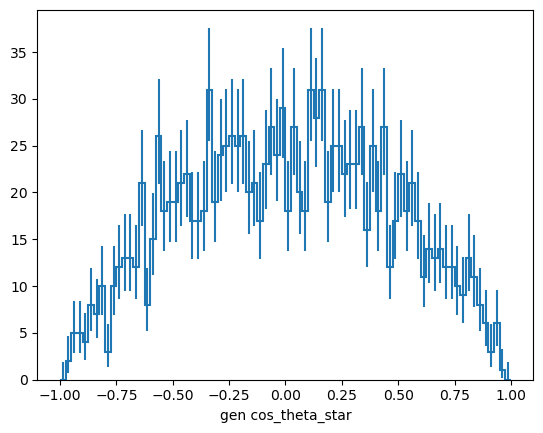

In [26]:
gen_cos_theta_star_hist = hist.Hist(hist.axis.StrCategory(name='dataset', label="BG", categories=[], growth=True),
                            hist.axis.Regular(name='gen_AK8_cos_theta_star', label='gen cos_theta_star', bins=80, start=-1, stop=1))
gen_cos_theta_star_hist.fill(dataset=test_dataset, gen_AK8_cos_theta_star=cos_theta_star_gen)
gen_cos_theta_star_hist.plot1d()

### TASK 5:

Can you plot the variables above also for the RSGraviton? The easiest way is to change the `test_dataset` above. Are there differences?

In [38]:
# print(cos_theta_star_rs)
# print(len(cos_theta_star_rs))

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fb3084d8ce0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

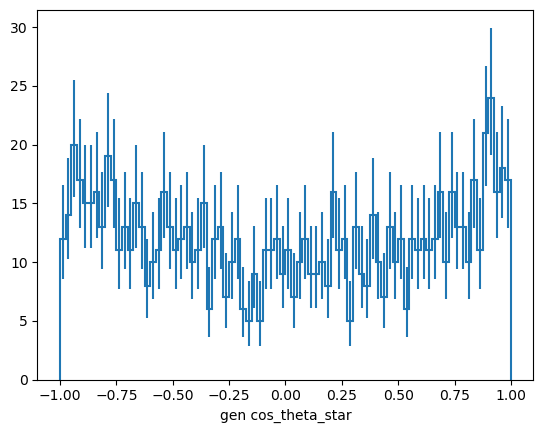

In [51]:
# Create a standalone histogram for RSGravToWW
rs_cos_theta_star_hist = hist.Hist(
    hist.axis.StrCategory(name='dataset', label="BG", categories=[], growth=True),
    hist.axis.Regular(name='gen_AK8_cos_theta_star', label='gen cos_theta_star', bins=80, start=-1, stop=1)
)
# Convert to NumPy if needed
cos_theta_star_rs_array = (
    cos_theta_star_rs if isinstance(cos_theta_star_rs, np.ndarray)
    else ak.to_numpy(cos_theta_star_rs)
)
# Fill the RS dataset
rs_cos_theta_star_hist.fill(dataset='RSGravToWW', gen_AK8_cos_theta_star=cos_theta_star_rs_array)
# Plot the RS histogram
rs_cos_theta_star_hist.plot1d()

### TASK 6:
To better compare them, can you plot them on the same figure? At least the `cos_theta_star_gen`

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fb3084ce690>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fb309580260>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

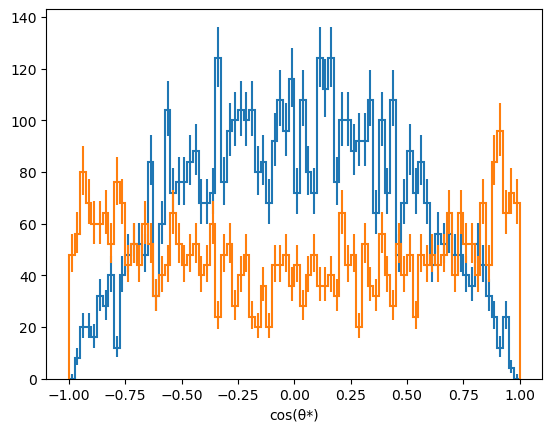

In [52]:
# Fill with BulkGravToWW values
cos_theta_star_hist.fill(dataset='BulkGravToWW', cos_theta_star=cos_theta_star_gen)

# Fill with RSGravToWW values
cos_theta_star_hist.fill(dataset='RSGravToWW', cos_theta_star=cos_theta_star_rs)

# Plot both
cos_theta_star_hist.plot1d(overlay='dataset')

### TASK 7: 

When you are happy with the result, go back to the beginning and add more files with different resonance mass (Let me know when you are here! Not sure it is easy for you to get the list of files!!)

## What we see in our detectors is not the generated particles but it is convolved with their interactions with the detectors or more deacys. For instance Jets instead if Quarks.

Below are two functions implemented for you that match the generated particles with the jets in the event.
1) Do you know what a jet is? I can provide more material and explanation to learn
2) Read the functions and try to understand what they do. Add all printouts that you need. Also printing the type of the variables is useful. Or running on a small number of events to explore them in depth.

In [71]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
def get_w_quark_pairs(events):
    pdgId = events.GenPart.pdgId
    mothers = events.GenPart.genPartIdxMother

    is_w = abs(pdgId) == 24
    is_quark = (abs(pdgId) <= 6) # Quarks u,d,s,c,b,t

    w_indices = ak.local_index(pdgId)[is_w]
    quark_indices = ak.local_index(pdgId)[is_quark]
    quark_parents = mothers[is_quark]

    w_quark_map = {} # (event_index, w_boson_index_in_event) -> [quark1_index_in_event, quark2_index_in_event]

    for evt_idx in range(len(pdgId)):
        # W's in the specific event
        event_w_indices = w_indices[evt_idx]
        # Quarks in the event
        event_quark_indices = quark_indices[evt_idx]
        event_quark_parents = quark_parents[evt_idx]
        
        for w_idx_in_event in event_w_indices:
            # Find quarks coming from W's Parent 
            daughter_quarks_indices_in_event = event_quark_indices[event_quark_parents == w_idx_in_event]
            if len(daughter_quarks_indices_in_event) == 2:
                w_quark_map[(evt_idx, w_idx_in_event)] = daughter_quarks_indices_in_event
    return w_quark_map

In [72]:
# Extract the map of W bosons to their decay quark indices
w_quark_map = get_w_quark_pairs(events)

In [73]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
# Matching GenJetAK8 and FatJet with the quark pairs coming from the W decay
def match_w_to_fatjets(events, w_quark_map):
     # Prepare containers for each event (same length as events)
    matched_fatjets_per_event = [[] for _ in range(len(events))]

    genjets = ak.zip({
        "pt": events.GenJetAK8.pt, "eta": events.GenJetAK8.eta,
        "phi": events.GenJetAK8.phi, "mass": events.GenJetAK8.mass
    }, with_name="Momentum4D")

    fatjets = ak.zip({
        "pt": events.FatJet.pt, "eta": events.FatJet.eta,
        "phi": events.FatJet.phi, "mass": events.FatJet.mass,
        "msoftdrop": events.FatJet.msoftdrop,
        "tau1": events.FatJet.tau1, "tau2": events.FatJet.tau2,
        "genJetIdx": events.FatJet.genJetAK8Idx,
        "subJetIdx1": events.FatJet.subJetIdx1,
        "subJetIdx2": events.FatJet.subJetIdx2
    })

    genparts = ak.zip({
        "pt": events.GenPart.pt, "eta": events.GenPart.eta,
        "phi": events.GenPart.phi, "mass": events.GenPart.mass
    }, with_name="Momentum4D")

    for (evt_idx, w_gen_idx), quark_gen_indices in w_quark_map.items():
        q1_gen_idx = quark_gen_indices[0]
        q2_gen_idx = quark_gen_indices[1]

        # Building quarks 4-vector 
        q1 = genparts[evt_idx][q1_gen_idx]
        q2 = genparts[evt_idx][q2_gen_idx]
        
        # Iteration in GenJetAK8 in the event - evt_idx
        for gj_local_idx, gj in enumerate(genjets[evt_idx]):
            if gj.deltaR(q1) < 0.8 and gj.deltaR(q2) < 0.8:
                
                # Mask for the FatJets in the actual event that is matching with gj_local_idx
                matching_fj_mask = (events.FatJet.genJetAK8Idx[evt_idx] == gj_local_idx)
                matched_fjs = events.FatJet[evt_idx][matching_fj_mask]
                
                
                if len(matched_fjs) > 0:
                    matched_fatjets_per_event[evt_idx].append(matched_fjs[0])
                    break

    # Convert list-of-lists of records back into ak.Array
    return ak.Array(matched_fatjets_per_event)

In [74]:
# Match FatJets to the quark pairs from W decay using GenJetAK8 association
matched_fatjets = match_w_to_fatjets(events, w_quark_map)

### TASK 8:

Plot on the same plot
1) the mass of the generated Ws
2) The mass of GenJetAK8
3) The mass of GenJetAK8 coming from a W (you need to write a function similar to the one above)
4) the mass of the FatJets
5) the mass of the FatJets coming from a W

Do you understand the plot?

#### Tip: you can run on only one file or with very few events when debugging your code

In [84]:
# Task 8.1
# Extracts the masses of all generated W bosons (pdgId = ±24)
def get_gen_w_masses(events):
    w_mask = abs(events.GenPart.pdgId) == 24
    w_masses = events.GenPart[w_mask].mass
    return ak.flatten(w_masses)

In [76]:
# Task 8.2
# Extracts the mass of all AK8 generator-level jets
def get_genjetak8_masses(events):
    return ak.flatten(events.GenJetAK8.mass)

In [77]:
# task 8.3 
# Matches GenJetAK8 jets to W → qq' quark pairs using ΔR and returns their masses
def get_genjetak8_masses_from_w(events, w_quark_map):
    matched_genjets = [[] for _ in range(len(events))]

    genjets = ak.zip({
        "pt": events.GenJetAK8.pt,
        "eta": events.GenJetAK8.eta,
        "phi": events.GenJetAK8.phi,
        "mass": events.GenJetAK8.mass
    }, with_name="Momentum4D")

    genparts = ak.zip({
        "pt": events.GenPart.pt,
        "eta": events.GenPart.eta,
        "phi": events.GenPart.phi,
        "mass": events.GenPart.mass
    }, with_name="Momentum4D")

    for (evt_idx, _), quark_indices in w_quark_map.items():
        q1 = genparts[evt_idx][quark_indices[0]]
        q2 = genparts[evt_idx][quark_indices[1]]

        for gj in genjets[evt_idx]:
            if gj.deltaR(q1) < 0.8 and gj.deltaR(q2) < 0.8:
                matched_genjets[evt_idx].append(gj)
                break

    return ak.flatten(ak.Array(matched_genjets).mass)

In [78]:
# Task 8.4 
# Returns the mass of all reconstructed FatJets
def get_fatjet_masses(events):
    return ak.flatten(events.FatJet.mass)

In [79]:
# Task 8.5 
# Uses the matched FatJets from match_w_to_fatjets() and returns their masses
def get_fatjet_masses_from_w(matched_fatjets):
    return ak.flatten(matched_fatjets.mass)

In [86]:
w_masses = get_gen_w_masses(events)
genjet_masses = get_genjetak8_masses(events)
genjet_matched_masses = get_genjetak8_masses_from_w(events, w_quark_map)
fatjet_masses = get_fatjet_masses(events)
fatjet_matched_masses = get_fatjet_masses_from_w(matched_fatjets)

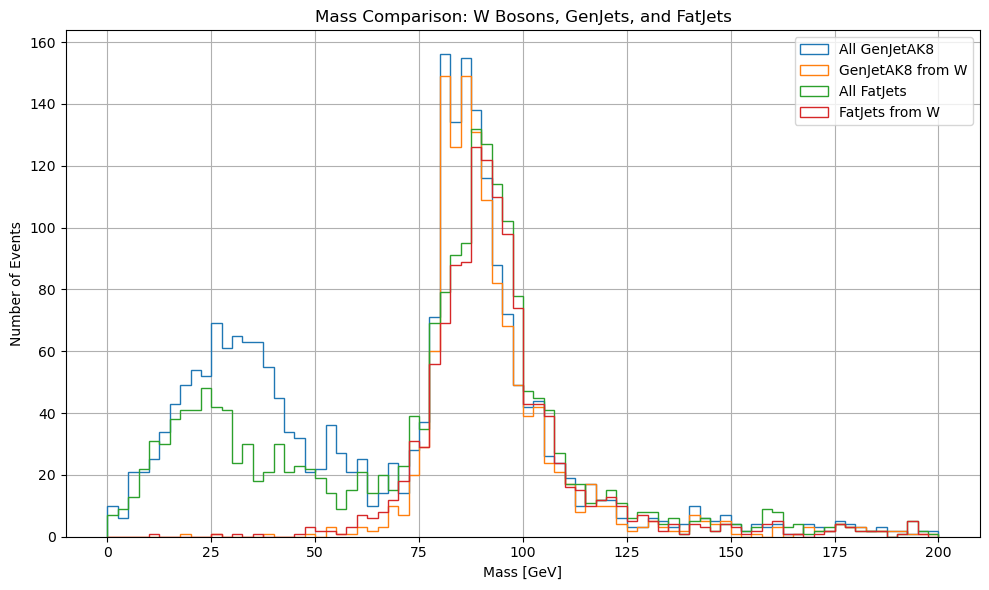

In [88]:
# Task 8 Plot
# Plot all mass distributions on the same histogram for comparison

plt.figure(figsize=(10, 6))

# plt.hist(w_masses, bins=80, range=(0, 200), histtype='step', label='Gen W Mass')
plt.hist(genjet_masses, bins=80, range=(0, 200), histtype='step', label='All GenJetAK8')
plt.hist(genjet_matched_masses, bins=80, range=(0, 200), histtype='step', label='GenJetAK8 from W')
plt.hist(fatjet_masses, bins=80, range=(0, 200), histtype='step', label='All FatJets')
plt.hist(fatjet_matched_masses, bins=80, range=(0, 200), histtype='step', label='FatJets from W')

plt.xlabel("Mass [GeV]")
plt.ylabel("Number of Events")
plt.title("Mass Comparison: W Bosons, GenJets, and FatJets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 9:

For the FatJets (or the FatJets coming from a W) let's plot also some variables that are commonly used to distinguish Jets coming from a W (or Z boson) from the background. Remind me to give you some material to learn about jet tagging when you get here!
1. Compare the mass and the soft drop mass ( `msoftdrop`)
2. Plot also the N-subjettines variables `tau1`, `tau2` and their ratio

In [98]:
# Task 9
## define the dataset
## extract properties of FatJets matched to W
matched_fatjet_mass       = ak.to_numpy(ak.flatten(matched_fatjets.mass))
matched_fatjet_msoftdrop  = ak.to_numpy(ak.flatten(matched_fatjets.msoftdrop))
matched_fatjet_tau1       = ak.to_numpy(ak.flatten(matched_fatjets.tau1))
matched_fatjet_tau2       = ak.to_numpy(ak.flatten(matched_fatjets.tau2))

# avoid divide-by-zero by masking invalid tau1 values
valid_tau_mask = matched_fatjet_tau1 > 0
tau21 = matched_fatjet_tau2[valid_tau_mask] / matched_fatjet_tau1[valid_tau_mask]

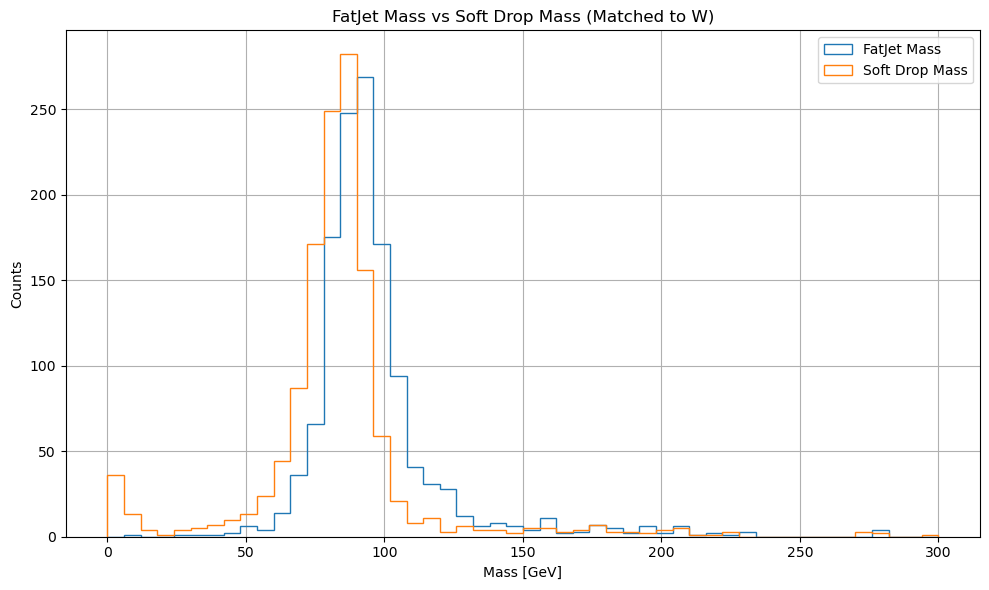

In [100]:
plt.figure(figsize=(10, 6))
plt.hist(matched_fatjet_mass, bins=50, range=(0, 300), histtype='step', label="FatJet Mass")
plt.hist(matched_fatjet_msoftdrop, bins=50, range=(0, 300), histtype='step', label="Soft Drop Mass")
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("FatJet Mass vs Soft Drop Mass (Matched to W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

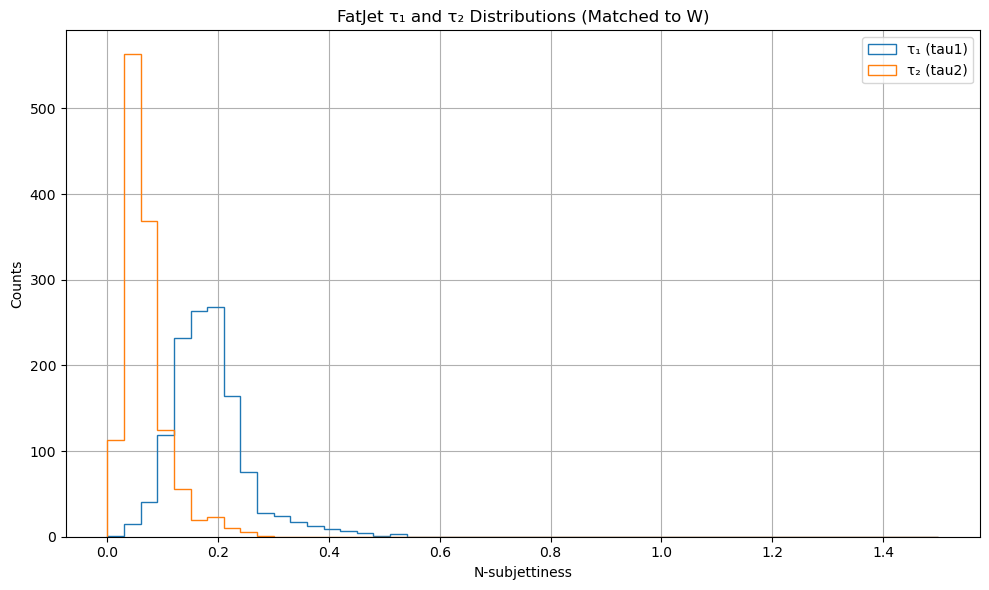

In [102]:
plt.figure(figsize=(10, 6))
plt.hist(matched_fatjet_tau1, bins=50, range=(0, 1.5), histtype='step', label="τ₁ (tau1)")
plt.hist(matched_fatjet_tau2, bins=50, range=(0, 1.5), histtype='step', label="τ₂ (tau2)")
plt.xlabel("N-subjettiness")
plt.ylabel("Counts")
plt.title("FatJet τ₁ and τ₂ Distributions (Matched to W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

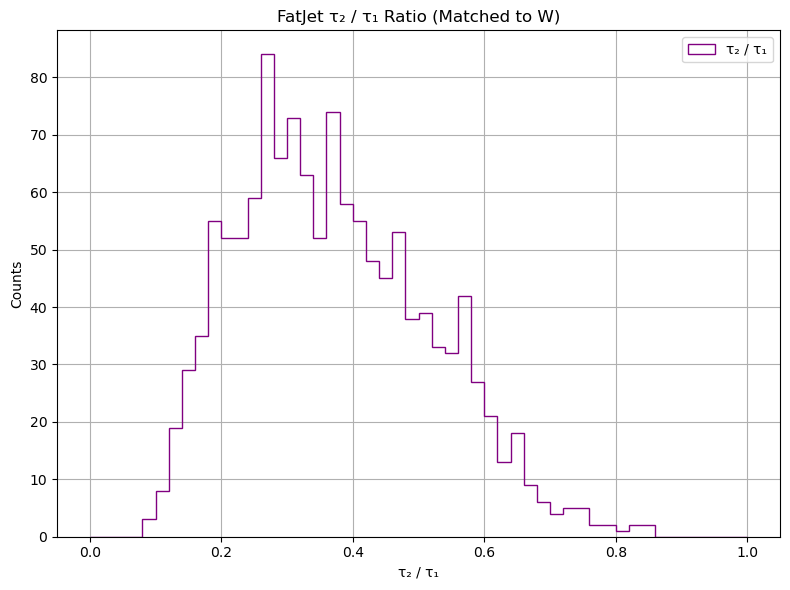

In [103]:
plt.figure(figsize=(8, 6))
plt.hist(tau21, bins=50, range=(0, 1), histtype='step', color='purple', label="τ₂ / τ₁")
plt.xlabel("τ₂ / τ₁")
plt.ylabel("Counts")
plt.title("FatJet τ₂ / τ₁ Ratio (Matched to W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 10:

Identify the subjets of the FatJets coming from the W and plot their kinematic variables

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_201/479021383.py:28: SyntaxWarning: invalid escape sequence '\e'
  plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.eta)), bins=50, range=(-3, 3), histtype='step', label='SubJet $\eta$')
/tmp/ipykernel_201/479021383.py:32: SyntaxWarning: invalid escape sequence '\p'
  plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.phi)), bins=50, range=(-3.2, 3.2), histtype='step', label='SubJet $\phi$')


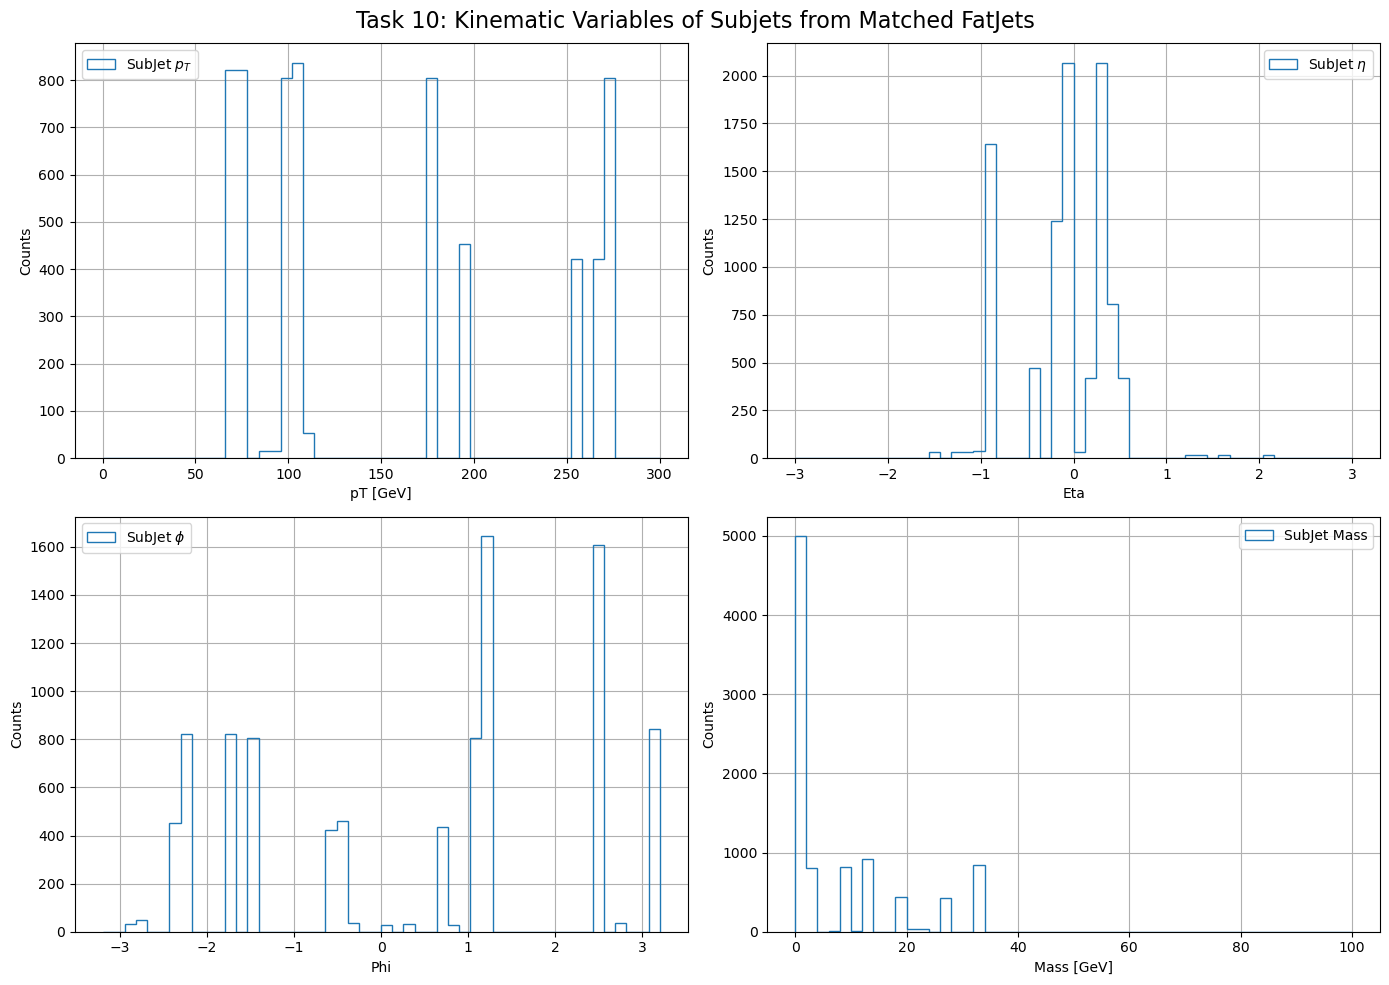

In [111]:
# Step 1: Extract subjet indices from matched FatJets
subjet1_indices = ak.flatten(matched_fatjets.subJetIdx1)
subjet2_indices = ak.flatten(matched_fatjets.subJetIdx2)

# Step 2: Load SubJets from event into a Momentum4D object
all_subjets = ak.zip({
    "pt": events.SubJet.pt,
    "eta": events.SubJet.eta,
    "phi": events.SubJet.phi,
    "mass": events.SubJet.mass
}, with_name="Momentum4D")

# Step 3: Extract subjets by index
subjets1 = all_subjets[subjet1_indices]
subjets2 = all_subjets[subjet2_indices]

# Step 4: Combine both into one array of matched subjets
all_matched_subjets = ak.concatenate([subjets1, subjets2], axis=0)

# Step 5: Plot all kinematic variables on a single figure
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.pt)), bins=50, range=(0, 300), histtype='step', label='SubJet $p_T$')
plt.xlabel("pT [GeV]"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.subplot(2, 2, 2)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.eta)), bins=50, range=(-3, 3), histtype='step', label='SubJet $\eta$')
plt.xlabel("Eta"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.subplot(2, 2, 3)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.phi)), bins=50, range=(-3.2, 3.2), histtype='step', label='SubJet $\phi$')
plt.xlabel("Phi"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.subplot(2, 2, 4)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.mass)), bins=50, range=(0, 100), histtype='step', label='SubJet Mass')
plt.xlabel("Mass [GeV]"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.suptitle("Task 10: Kinematic Variables of Subjets from Matched FatJets", fontsize=16)
plt.tight_layout()
plt.show()

### TASK 11:

Can you calculate cos theta for the jets and subjets instead of the gen particles? This may be tricky!! Take your time!

In [ ]:

vector.register_awkward()

# Step 1: Build vector array of all SubJets
all_subjets = vector.awkward.zip({
    "pt": events["SubJet_pt"],
    "eta": events["SubJet_eta"],
    "phi": events["SubJet_phi"],
    "mass": events["SubJet_mass"]
})

# Step 2: Extract subjet indices from matched FatJets
sj1_idx = ak.flatten(matched_fatjets.subJetIdx1)
sj2_idx = ak.flatten(matched_fatjets.subJetIdx2)

# Step 3: Apply mask for valid indices
valid_mask = (sj1_idx >= 0) & (sj2_idx >= 0)
sj1_idx = sj1_idx[valid_mask]
sj2_idx = sj2_idx[valid_mask]

# Step 4: Get subjet 4-vectors using indices
sj1 = all_subjets[sj1_idx]
sj2 = all_subjets[sj2_idx]

# Step 5: Reconstruct parent W boson 4-vector
w_boson = sj1 + sj2

# Step 6: Boost sj1 into W rest frame
sj1_boosted = sj1.boost(-w_boson.boostvec)

# Step 7: Compute cos(theta*) = cos(angle between boosted sj1 and W direction)
cos_theta_star = sj1_boosted.unit.dot(w_boson.unit)

# Step 8: Flatten and plot
plt.figure(figsize=(8, 6))
plt.hist(ak.to_numpy(ak.flatten(cos_theta_star)), bins=50, range=(-1, 1), histtype='step', color='darkblue')
plt.xlabel(r"$\cos\theta^*$")
plt.ylabel("Counts")
plt.title("Cosine of Decay Angle θ* (SubJet in W Rest Frame)")
plt.grid(True)
plt.tight_layout()
plt.show()
